This notebook consists of an exploratory data analysis for the normal data available in the 3W Dataset. For more details about the dataset, check [VARGAS et al. (2019)](https://linkinghub.elsevier.com/retrieve/pii/S0920410519306357). For more in-depth exploratory analysis of the 3W Dataset and others process systems engineering datasets, check [MELO et al. (2022)](https://www.sciencedirect.com/science/article/abs/pii/S0098135422003003).

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']


## Reference table of variables

In [39]:
CLASSES_DESCRIPTION = ['NORMAL', 'ABRUPT_INCREASE_OF_BSW', 'SPURIOUS_CLOSURE_OF_DHSV', 'SEVERE_SLUGGING',
                 'FLOW_INSTABILITY', 'RAPID_PRODUCTIVITY_LOSS', 'QUICK_RESTRICTION_IN_PCK', 'SCALING_IN_PCK',
                 'HYDRATE_IN_PRODUCTION_LINE', 'HYDRATE_IN_SERVICE_LINE']

# You can adjust the threshold (e.g., 0.5 for at least 50% non-missing values)
threshold = 0.5
EVENTS = np.arange(0,10)
PATHS = [os.path.join('/home/padeiroc/ai_project/OilGasWatch-AI', 'dataset', str(path)) for path in EVENTS ]

tags = {'P-PDG':'Pa', 
        'P-TPT':'Pa', 
        'T-TPT':'degC',
        'P-MON-CKP':'Pa', 
        'T-JUS-CKP':'degC', 
        'P-JUS-CKGL':'Pa', 
        'QGL': 'sm^3/s'}

names = ['Pressure at the PDG',
         'Pressure at the TPT',
         'Temperature at the TPT',
         'Pressure upstream of the PCK',
         'Temperature downstream of the PCK',
         'Pressure downstream of the GLCK',
         'Gas lift flow rate']

reference_table = pd.DataFrame(index=np.arange(1,len(names)+1))
reference_table.index.name='Number'
reference_table['Tag'] = tags.keys()
reference_table['Name'] = names
reference_table['Unit'] = tags.values()
reference_table

,Tag,Name,Unit
Number,,,
1,P-PDG,Pressure at the PDG,Pa
2,P-TPT,Pressure at the TPT,Pa
3,T-TPT,Temperature at the TPT,degC
4,P-MON-CKP,Pressure upstream of the PCK,Pa
5,T-JUS-CKP,Temperature downstream of the PCK,degC
6,P-JUS-CKGL,Pressure downstream of the GLCK,Pa
7,QGL,Gas lift flow rate,sm^3/s


## Data importing

In [43]:
%%time

dfs = {}
events = {}
columns_names = {}
data_generation = {}

columns_to_keep = list(tags.keys()) + ['class']
for PATH in PATHS:
    if os.path.exists(PATH):
        files = [f for f in os.listdir(PATH) if os.path.isfile(os.path.join(PATH, f))]
        for file in files:
            df = pd.read_parquet(os.path.join(PATH, file), engine="pyarrow")
            for column in df.columns:
                columns_names[column] = columns_names.get(column,0) + 1 
            df = df.reindex(columns=columns_to_keep)
            
            if "SIMULATED" in str(file):
                data_generation["SIMULATED"] = data_generation.get("SIMULATED",0)  + 1
            elif "drawn" in str(file).lower(): 
                data_generation["DRAWN"] = data_generation.get("DRAWN",0)  + 1
            else:
                data_generation["REAL"] = data_generation.get("REAL",0)  + 1
            
            file_name = os.path.splitext(file)[0]
            dfs[file_name] = df
            events[str(PATH).split("/")[-1]] = events.get(str(PATH).split("/")[-1], 0) + 1

df_combined = pd.concat(dfs.values(), ignore_index=True)
    
print('Data read!\nNumber of instances: ',len(dfs))
print('Original columans: \n',columns_names)
print('Data Generation: ',data_generation)
print('Number of real instances: ',data_generation["REAL"])
print('Number of instances by event: \n', events)

gc.collect()

Data read!
Number of instances:  1568
Original columans: 
 {'ABER-CKGL': 2228, 'ABER-CKP': 2228, 'ESTADO-DHSV': 2228, 'ESTADO-M1': 2228, 'ESTADO-M2': 2228, 'ESTADO-PXO': 2228, 'ESTADO-SDV-GL': 2228, 'ESTADO-SDV-P': 2228, 'ESTADO-W1': 2228, 'ESTADO-W2': 2228, 'ESTADO-XO': 2228, 'P-ANULAR': 2228, 'P-JUS-BS': 2228, 'P-JUS-CKGL': 2228, 'P-JUS-CKP': 2228, 'P-MON-CKGL': 2228, 'P-MON-CKP': 2228, 'P-MON-SDV-P': 2228, 'P-PDG': 2228, 'PT-P': 2228, 'P-TPT': 2228, 'QBS': 2228, 'QGL': 2228, 'T-JUS-CKP': 2228, 'T-MON-CKP': 2228, 'T-PDG': 2228, 'T-TPT': 2228, 'class': 2228, 'state': 2228}
Data Generation:  {'REAL': 1119, 'SIMULATED': 1089, 'DRAWN': 20}
Number of real instances:  1119
Number of instances by event: 
 {'0': 594, '1': 128, '2': 38, '3': 106, '4': 343, '5': 450, '6': 221, '7': 46, '8': 95, '9': 207}
CPU times: user 33.6 s, sys: 1.35 s, total: 34.9 s
Wall time: 9.94 s


0

In [41]:
print("1. Describe")
display(df_combined.describe())
display(df_combined.shape)
print("2. Head")
display(df_combined.head())
print("3. Tail")
display(df_combined.tail())

1. Describe


,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,QGL,class
count,4.253902e+07,4.507345e+07,4.424304e+07,4.337538e+07,3.442233e+07,3.189623e+07,2.456596e+07,46426833.0
mean,-8.480137e+39,1.500789e+07,8.916830e+01,3.489190e+06,6.548958e+01,1.661814e+07,1.304284e+00,41.679421
std,9.967764e+40,6.925500e+07,3.894389e+01,3.370440e+06,1.921989e+01,7.365240e+07,1.541538e+00,50.692272
min,-1.180116e+42,-1.712930e+07,-3.375000e+01,-2.370260e+05,-1.139319e+01,-4.976717e+05,-5.417673e+01,0.0
25%,0.000000e+00,8.843662e+06,6.485219e+01,1.114936e+06,5.427044e+01,3.401556e+06,0.000000e+00,0.0
50%,1.714187e+07,1.417039e+07,1.057713e+02,2.185632e+06,6.697352e+01,1.656928e+07,9.925243e-01,5.0
75%,2.503853e+07,1.806580e+07,1.176140e+02,4.277641e+06,8.065589e+01,1.976204e+07,2.281354e+00,107.0
max,4.909435e+07,2.941990e+09,1.274685e+02,2.474700e+07,1.100865e+02,1.052061e+10,7.297315e+00,109.0


(50455233, 8)

2. Head


,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,QGL,class
0,44858050.0,21146550.0,116.5660,12234250.0,62.09661,2357085.0,0.0,<NA>
1,44858050.0,21146550.0,116.5658,12234250.0,62.10103,2357089.0,0.0,<NA>
2,44858050.0,21146550.0,116.5657,12234250.0,62.10544,2357093.0,0.0,<NA>
3,44858050.0,21146550.0,116.5655,12234250.0,62.10985,2357097.0,0.0,<NA>
4,44858050.0,21146550.0,116.5654,12234250.0,62.11427,2357101.0,0.0,<NA>


3. Tail


,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,QGL,class
50455228,22734940.0,11418490.0,69.87502,1489906.0,57.13217,19573580.0,2.537025,0
50455229,22734940.0,11418560.0,69.87584,1490001.0,57.13218,19573990.0,2.539693,0
50455230,22734940.0,11418630.0,69.87666,1490095.0,57.13219,19574400.0,2.542361,0
50455231,22734940.0,11418690.0,69.87748,1490190.0,57.13220,19574800.0,2.545028,0
50455232,22734940.0,11418760.0,69.87831,1490284.0,57.13221,19575210.0,2.547696,0


In [42]:
df_combined.isnull().sum()

P-PDG          7916216
P-TPT          5381783
T-TPT          6212188
P-MON-CKP      7079851
T-JUS-CKP     16032900
P-JUS-CKGL    18558999
QGL           25889273
class          4028400
dtype: int64

In [ ]:
numeric_cols = df_combined.select_dtypes(include=np.number).columns.tolist()
valid_numeric_cols = [col for col in numeric_cols if df_combined[col].notna().sum() / len(df_combined) > threshold]

# Determine the number of subplots needed (one for each valid numeric column)
print(f" Total: {len(valid_numeric_cols)} | List: {valid_numeric_cols}") 

 Total: 6 | List: ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL']


In [8]:
numeric_cols = df_combined.select_dtypes(include=np.number).columns.tolist()
valid_numeric_cols = [col for col in numeric_cols if df_combined[col].notna().sum() / len(df_combined)]

# Determine the number of subplots needed (one for each valid numeric column)
print(f" Total: {len(valid_numeric_cols)} | List: {valid_numeric_cols}") 

 Total: 7 | List: ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'QGL']


## Visualization

### Comparison of simulation and real data

In the following graphs, simulations are plotted in black and real data are plotted in orange. All data are standardized to zero mean and unit variance.

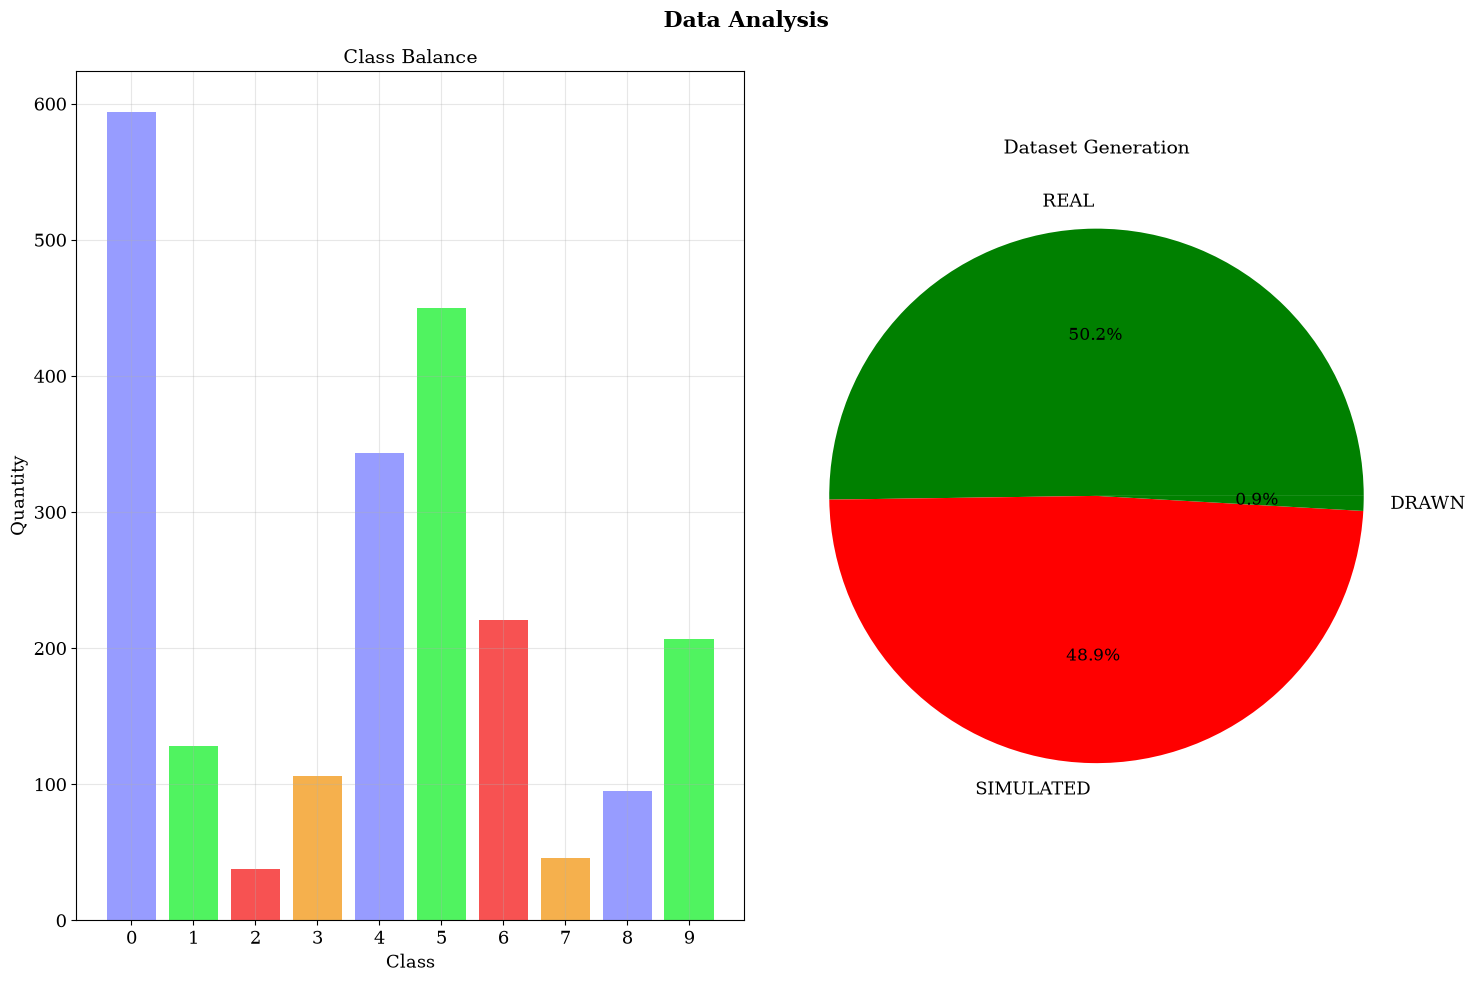

4866

In [44]:
import matplotlib.pyplot as plt

color = {
        "blue": "#6B72FF",
        "green": "#06EF1D",
        "red": "#F50909",
        "pinck": "#400CDD",
        "yellow": "#F18F01",
        }

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.suptitle(f" Data Analysis", fontsize=16, fontweight="bold")

# Time series plots
axes[0].bar(
    list(events.keys()),
    list(events.values()),
    color=[color["blue"], color["green"], color["red"], color["yellow"]],
    alpha=0.7,
    linewidth=0.5,
)
axes[0].set_title(f"Class Balance")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Quantity")
axes[0].grid(True, alpha=0.3)

axes[1].pie(
    list(data_generation.values()),
    labels = list(data_generation.keys()),
    colors=["green", "red"],
    autopct='%1.1f%%')

axes[1].set_title(f"Dataset Generation")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
                    
gc.collect()


There are upward and downward trends in temperature variables (3, T-TPT and 5, T-JUS-CKP) for simulated and hand-drawn data, but only upward trends for those variables in real data.

In variable 2, P-TPT, there are upward and downward trends for simulated data, but only downward trends in real and hand-drawn data.

### Plotting all instances

The function below is for plotting faulty instances for the three available data types: simulated, hand-drawn and real data.

In the following graphs, the light red background indicates faulty transient periods, in which the abnormal events are still developing; the dark red background indicates faulty steady-state periods, in which the abnormal events are fully developed.

#### Simulated data

In [ ]:
%%time

plot_faulty_instances(29,4,(18,200),'SIMULATED')

Some transient periods are longer than others. Variable 4 seems the most affected by the event, with visible disturbances during the transient and steady-state phases.

#### Hand-drawn data

In [ ]:
%%time

plot_faulty_instances(4,3,(20,20),'DRAWN')

The drawn data is remarkably simple, consisting only of correlated trends.

#### Real data

In [ ]:
# %%time

plot_faulty_instances(2,3,(20,16),'WELL')

As in simulated and drawn data, during normal periods, many of the variables are stable; in transient phases, upward and downward trends begin to take place.

Unlike simulated and hand-drawn data, there is consistency in the orientation of trends for all variables across the five instances.